In [4]:
import numpy as np 
import matplotlib.pyplot as plt 
import pandas as pd 

from visual_config import NIGHT_BLUE, HALF_PAGE

In [12]:
coordinates_path = "/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/00_preprocessed/data_10_consensus/04_coordinates_68.csv"
connectivity_path = "/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/01_first_analysises/connectomes_weighted_68x68.npy"

coordinates = pd.read_csv(coordinates_path, header=None) 
connectivity = np.load(connectivity_path)[0,:,:]

In [18]:
coordinates



,0,1,2
0,59.608368,87.316829,29.544590
1,53.680925,70.191671,34.301059
2,31.041087,99.774201,39.764418
3,52.348372,101.899270,31.653449
4,63.717688,66.718640,45.547499
...,...,...,...
63,117.688621,159.629926,20.892274
64,135.967006,157.204211,34.964033
65,106.478025,155.580444,30.743673
66,116.711067,147.941751,39.185714


NameError: name 'ut' is not defined

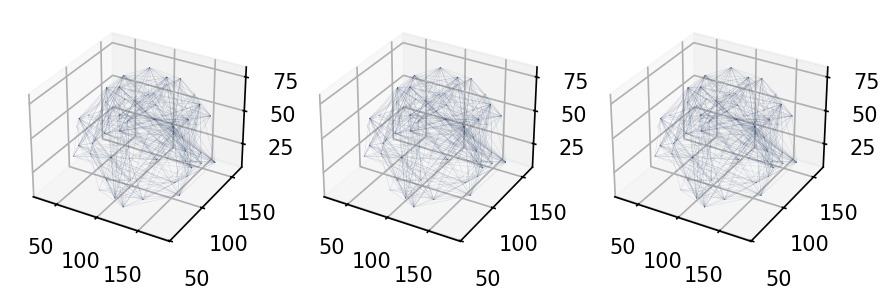

In [20]:
fig, axes = plt.subplot_mosaic(
    [["A", "B", "C"]], figsize=HALF_PAGE, subplot_kw=dict(projection="3d"), dpi=150
)


for i in range(connectivity.shape[0]):
    for j in range(i, connectivity.shape[1]):
        if connectivity[i, j] != 0:
            axes["A"].plot(
                [coordinates[0][i], coordinates[0][j]],
                [coordinates[1][i], coordinates[1][j]],
                [coordinates[2][i], coordinates[2][j]],
                c=NIGHT_BLUE,
                alpha=0.2 + connectivity[i, j],
                linewidth=0.2,
            )
            axes["B"].plot(
                [coordinates[0][i], coordinates[0][j]],
                [coordinates[1][i], coordinates[1][j]],
                [coordinates[2][i], coordinates[2][j]],
                c=NIGHT_BLUE,
                alpha=0.2 + connectivity[i, j],
                linewidth=0.2,
            )
            axes["C"].plot(
                [coordinates[0][i], coordinates[0][j]],
                [coordinates[1][i], coordinates[1][j]],
                [coordinates[2][i], coordinates[2][j]],
                c=NIGHT_BLUE,
                alpha=0.2 + connectivity[i, j],
                linewidth=0.2,
            )

ut.brain_plotter(
    np.array(coordinates[:, 0]),
    coordinates,
    axes["A"],
    view=sagittal,
    size=10,
    cmap=monochrome,
    scatter_kwargs=scatter_kw_network,
)
ut.brain_plotter(
    np.flip(np.array(coordinates[:, 2])),
    coordinates,
    axes["B"],
    view=axial,
    size=10,
    cmap=monochrome,
    scatter_kwargs=scatter_kw_network,
)
ut.brain_plotter(
    np.flip(np.array(coordinates[:, 1])),
    coordinates,
    axes["C"],
    view=coronal,
    size=10,
    cmap=monochrome,
    scatter_kwargs=scatter_kw_network,
)

fig.tight_layout(pad=0.1)
# plt.savefig(f"figures/structural_brain_network.pdf", dpi=600, bbox_inches="tight")